In [17]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

PATH = r"C:\Users\MuhammedSaidali\.cache\huggingface\hub\datasets--bengsoon--volve_daily_drilling_report\snapshots\f0cbe11bfebb23f007b57a52cb903d9075db777c\data\all-00000-of-00001.parquet"
df = pd.read_parquet(PATH)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(2)


Dataset loaded: 1759 rows, 17 columns


,docName,nameWell,nameWellbore,name,dTimStart,dTimEnd,versionKind,createDate,wellAlias,wellboreAlias,wellboreInfo,statusInfo,fluid,porePressure,surveyStation,activity,lithShowInfo
0,15_9_19_A_1980_01_01,NO 15/9-19 A,NO 15/9-19 A,name,1979-12-31T00:00:00+01:00,1980-01-01T00:00:00+01:00,normal,2018-05-03T13:53:19+02:00,"{'name': '15/9-19 A', 'namingSystem': 'NPD code'}","[{'name': '15/9-19 A', 'namingSystem': 'NPD co...","[{'dTimSpud': '1997-07-25T00:00:00+02:00', 'da...","[{'avgPresBH': None, 'avgTempBH': None, 'dTim'...",[],[],"[{'azi': '283.75', 'dTim': '1980-01-01T00:00:0...",[],[]
1,15_9_19_A_1997_07_25,NO 15/9-19 A,NO 15/9-19 A,name,1997-07-24T00:00:00+02:00,1997-07-25T00:00:00+02:00,normal,2018-05-03T13:53:19+02:00,"{'name': '15/9-19 A', 'namingSystem': 'NPD code'}","[{'name': '15/9-19 A', 'namingSystem': 'NPD co...","[{'dTimSpud': '1997-07-25T00:00:00+02:00', 'da...","[{'avgPresBH': None, 'avgTempBH': None, 'dTim'...",[],[],[],[],[]


## 2. Data Understanding


In [18]:
print(f"Number of reports: {len(df)}")
print(f"Number of unique wells: {df['nameWell'].nunique()}")
print(f"Number of unique wellbores: {df['nameWellbore'].nunique()}")

has_activity = df['activity'].apply(lambda x: len(x) > 0)
print(f"Reports with activity data: {has_activity.sum()} / {len(df)}")

total_comments = df['activity'].apply(
    lambda x: sum(1 for a in x if a.get('comments', '').strip() != '')
).sum()
print(f"Total drill report comments: {total_comments}")

missing = df.isnull().sum()
miss_cols = missing[missing > 0]
if len(miss_cols) > 0:
    print(f"Missing values:\n{miss_cols}")
else:
    print("No missing values")

print(f"Date range: {df['dTimStart'].min()} to {df['dTimEnd'].max()}")

for i, row in df.iterrows():
    if len(row['activity']) > 0:
        sample = row['activity'][0]
        print(f"Sample comment from row {i}")
        print(f"Well: {row['nameWell']}")
        print(f"Date: {row['dTimStart']}")
        print(f"Comment: {sample.get('comments', '')[:300]}")
        break


Number of reports: 1759
Number of unique wells: 23
Number of unique wellbores: 26
Reports with activity data: 1750 / 1759
Total drill report comments: 23447
No missing values
Date range: 1979-12-31T00:00:00+01:00 to 2018-01-25T00:00:00+01:00
Sample comment from row 2
Well: NO 15/9-19 A
Date: 1997-07-25T00:00:00+02:00
Comment: MU BAKER WINDOWMASTER WHIPSTOCK + MILLING ASSEMBLY & ASSOCIATED BHA. CONTINUE TIH WITH DP.


## 3. Text Extraction
Extract the free-text drilling narratives from the `activity[i][\"comments\"]` field and flatten into a single text corpus.


In [19]:
def extract_comments(df):
    comments = []
    doc_ids = []
    for idx, row in df.iterrows():
        for act in row['activity']:
            c = act.get('comments', '')
            if c and c.strip():
                comments.append(c.strip())
                doc_ids.append(idx)
    return pd.Series(comments, name='comment'), pd.Series(doc_ids, name='doc_id')

corpus, doc_ids = extract_comments(df)
print(f"Extracted {len(corpus)} comments")
print("First 3 samples:")
for i in range(3):
    print(f"Comment {i+1}: {corpus.iloc[i][:200]}")


Extracted 23447 comments
First 3 samples:
Comment 1: MU BAKER WINDOWMASTER WHIPSTOCK + MILLING ASSEMBLY & ASSOCIATED BHA. CONTINUE TIH WITH DP.
Comment 2: CONTINUED TIH WITH  WINDOWMASTER WHIPSTOCK & MILLING ASSEMBLY. TAGGED 9 5/8" BRIDGE-PLUG AT 2211 M DPM.
Comment 3: ORIENTED WHIPSTOCK USING MWD. SET ANCHOR ON WHIPSTOCK.


## 4. Text Preprocessing
Steps:
- Lowercase
- Remove punctuation and special characters
- Remove numbers
- Remove stopwords
- Tokenization
- Lemmatization


In [20]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

drilling_stopwords = {
    'ft', 'in', 'hrs', 'hr', 'min', 'bbl', 'psi', 'ppg', 'sg',
    'deg', 'degf', '%', 'amp', 'per', 'via', 'tih', 'pooh',
    'x', 'y', 'z', 'eq', 'incl', 'approx', 'w/', 'w/o'
}
stop_words.update(drilling_stopwords)

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens

def preprocess_joined(text):
    return ' '.join(preprocess(text))

sample_result = preprocess(corpus.iloc[0])
print(f"Original: {corpus.iloc[0][:150]}...")
print(f"Processed: {sample_result[:15]}")

print(f"Preprocessing {len(corpus)} comments...")
processed = corpus.apply(preprocess_joined)
processed_tokens = corpus.apply(preprocess)
print("Done!")


Original: MU BAKER WINDOWMASTER WHIPSTOCK + MILLING ASSEMBLY & ASSOCIATED BHA. CONTINUE TIH WITH DP....
Processed: ['baker', 'windowmaster', 'whipstock', 'milling', 'assembly', 'associated', 'bha', 'continue']
Preprocessing 23447 comments...
Done!


## 5. Exploratory Data Analysis


=== Dataset Statistics ===
Total reports (source docs): 1759
Total extracted comments: 23447
Unique wells: 23
Comment length (words after preprocessing):
  Mean: 11.3
  Median: 9
  Min: 0
  Max: 108


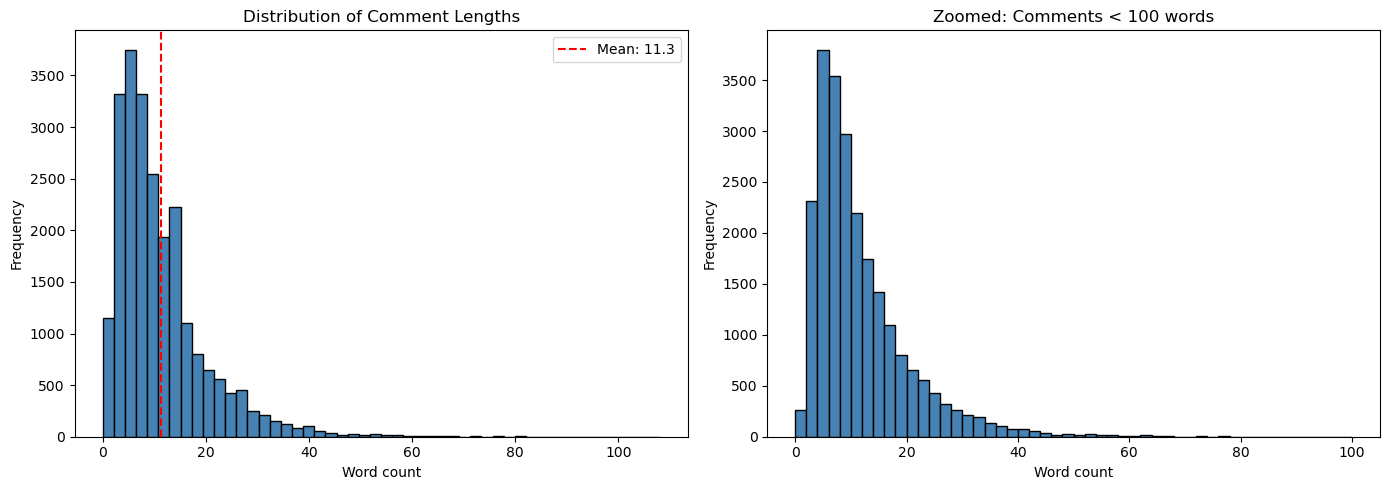

In [21]:
print("=== Dataset Statistics ===")
print(f"Total reports (source docs): {len(df)}")
print(f"Total extracted comments: {len(corpus)}")
print(f"Unique wells: {df['nameWell'].nunique()}")

lengths = processed.apply(lambda x: len(x.split()))
print(f"Comment length (words after preprocessing):")
print(f"  Mean: {lengths.mean():.1f}")
print(f"  Median: {lengths.median():.0f}")
print(f"  Min: {lengths.min()}")
print(f"  Max: {lengths.max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lengths, bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Comment Lengths')
axes[0].axvline(lengths.mean(), color='red', linestyle='--', label=f'Mean: {lengths.mean():.1f}')
axes[0].legend()

axes[1].hist(lengths, bins=50, edgecolor='black', color='steelblue', range=(0, 100))
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Zoomed: Comments < 100 words')
plt.tight_layout()
plt.show()


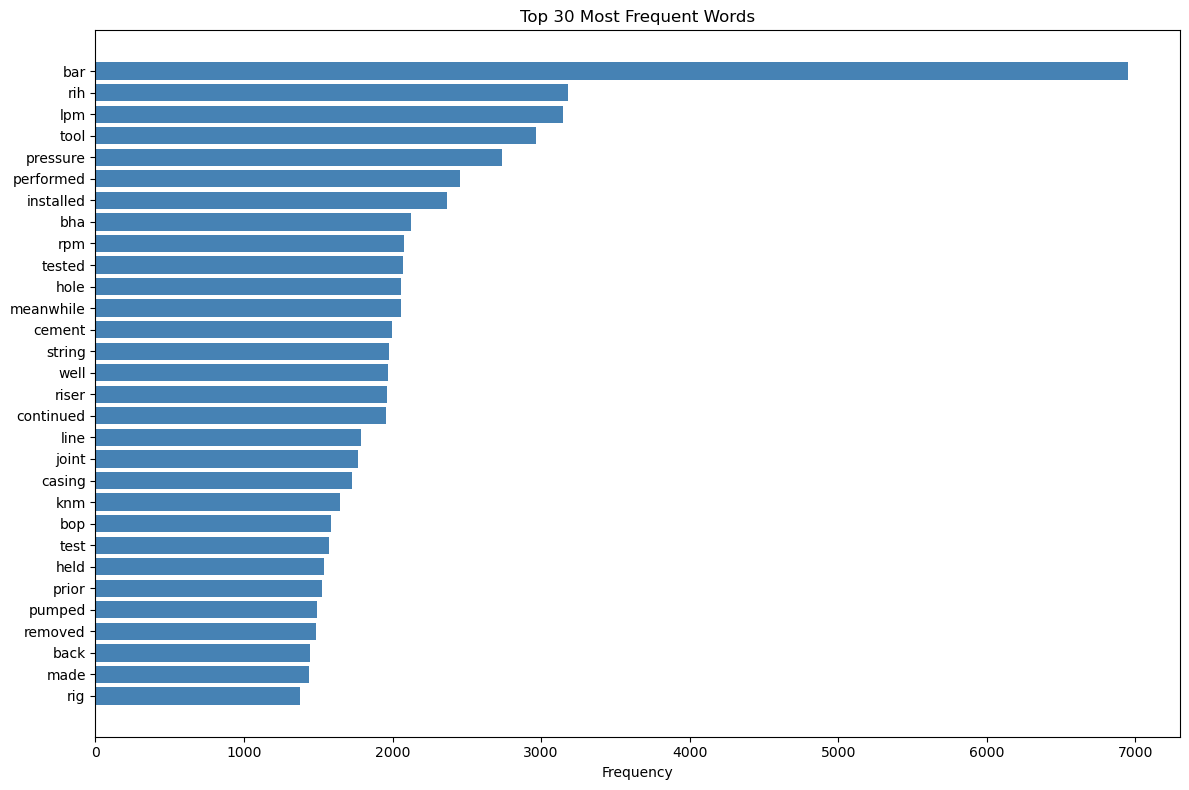

In [22]:
from collections import Counter

all_words = [w for tokens in processed_tokens for w in tokens]
word_freq = Counter(all_words).most_common(30)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 8))
plt.barh(range(len(words)), counts, color='steelblue')
plt.yticks(range(len(words)), words)
plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.title('Top 30 Most Frequent Words')
plt.tight_layout()
plt.show()


## 6. Feature Extraction: TF-IDF Vectorization


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=5,
    ngram_range=(1, 1),
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(processed)
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(feature_names)}")
print("Top 10 by IDF (rarest terms):")
idf_vals = vectorizer.idf_
top_rare = np.argsort(idf_vals)[-10:]
for i in top_rare:
    print(f"  {feature_names[i]}: {idf_vals[i]:.2f}")


TF-IDF matrix shape: (23447, 2357)
Vocabulary size: 2357
Top 10 by IDF (rarest terms):
  placing: 9.27
  conflict: 9.27
  sabs: 9.27
  fix: 9.27
  diluted: 9.27
  information: 9.27
  samson: 9.27
  cal: 9.27
  remark: 9.27
  bringing: 9.27


## 7. Topic Modeling with Latent Dirichlet Allocation (LDA)


In [24]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=100,
    learning_method='online'
)

lda.fit(tfidf_matrix)
print(f"LDA model trained with {n_topics} topics")
print(f"Log likelihood: {lda.score(tfidf_matrix):.2f}")


LDA model trained with 5 topics
Log likelihood: -477423.01


## 8. Result Visualization


In [25]:
def display_top_words(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx + 1}: {' | '.join(top_words)}")

display_top_words(lda, feature_names, 12)


Topic 1: lpm | rih | speed | bar | pipe | cement | mud | filled | hole | circulated | circulation | weight
Topic 2: tested | pressure | bar | bop | test | riser | line | tool | well | closed | joint | cement
Topic 3: bha | rih | held | tool | handling | talk | prior | equipment | box | continued | tbt | gun
Topic 4: installed | removed | floor | slip | rig | bushing | cleaned | cleared | elevator | master | hanger | pr
Topic 5: rpm | meeting | knm | hole | drilled | job | lpm | bar | performed | pre | flow | well


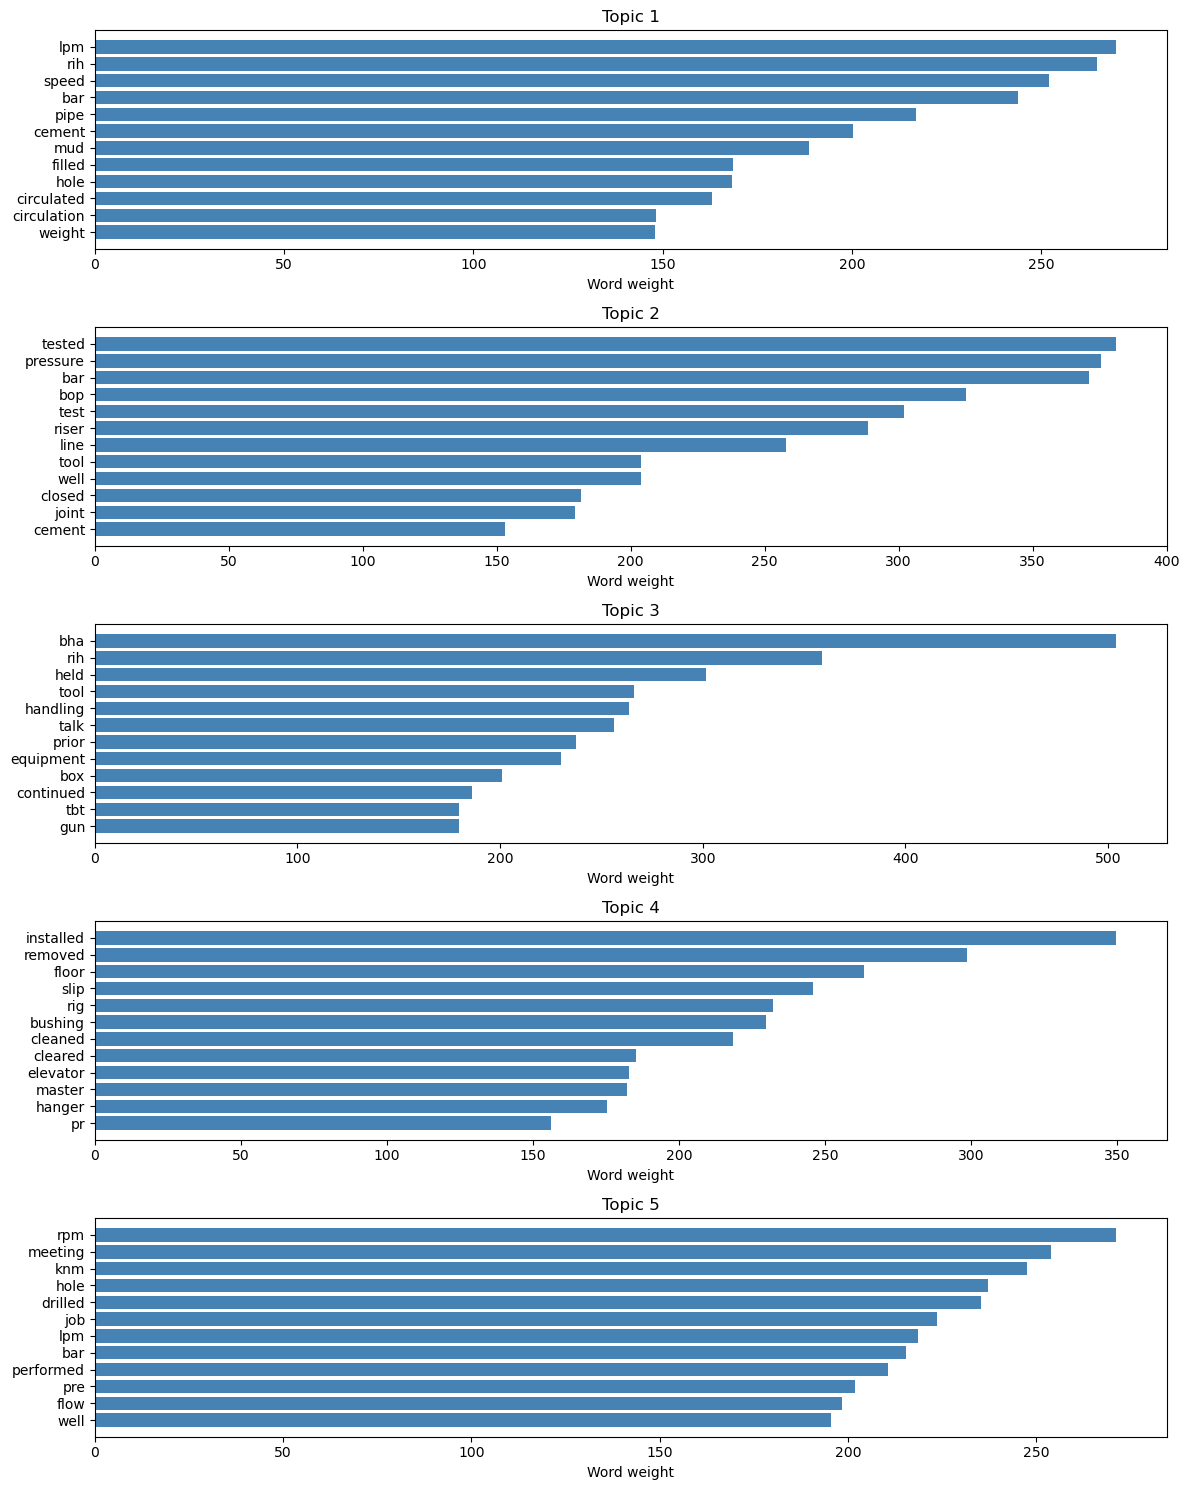

In [26]:
n_top_words = 12
fig, axes = plt.subplots(nrows=n_topics, ncols=1, figsize=(12, 3 * n_topics))

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[:-n_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [topic[i] for i in top_indices]

    ax = axes[topic_idx]
    ax.barh(range(len(top_words)), top_scores, color='steelblue')
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words)
    ax.invert_yaxis()
    ax.set_xlabel('Word weight')
    ax.set_title(f'Topic {topic_idx + 1}')

plt.tight_layout()
plt.show()


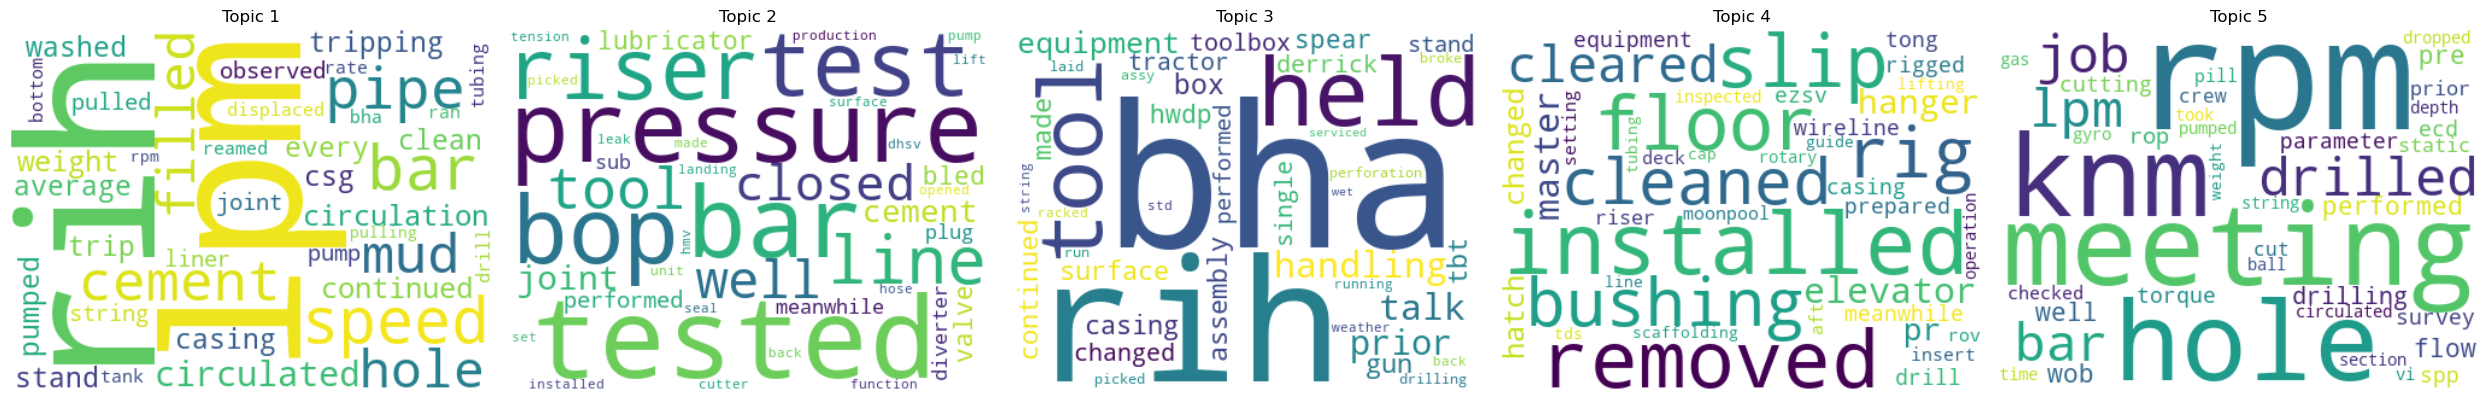

In [27]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, n_topics, figsize=(5 * n_topics, 5))

for topic_idx, topic in enumerate(lda.components_):
    word_scores = {feature_names[i]: topic[i] for i in range(len(feature_names))}
    wc = WordCloud(width=400, height=300, background_color='white', max_words=40)
    wc.generate_from_frequencies(word_scores)

    if n_topics > 1:
        axes[topic_idx].imshow(wc, interpolation='bilinear')
        axes[topic_idx].axis('off')
        axes[topic_idx].set_title(f'Topic {topic_idx + 1}')
    else:
        axes.imshow(wc, interpolation='bilinear')
        axes.axis('off')
        axes.set_title(f'Topic {topic_idx + 1}')

plt.tight_layout()
plt.show()


Topic distribution across all comments:
  Topic 1: 19.7%
  Topic 2: 30.9%
  Topic 3: 17.2%
  Topic 4: 18.3%
  Topic 5: 14.0%


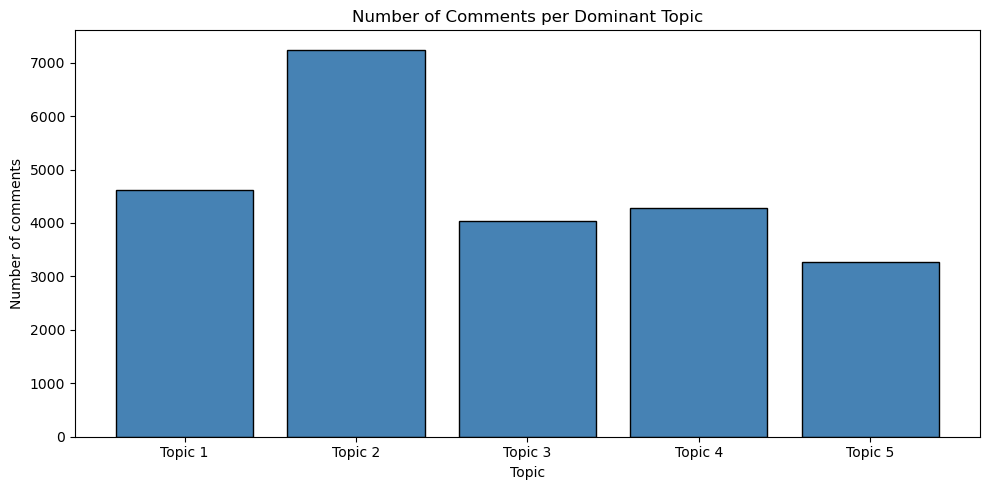

In [28]:
topic_dist = lda.transform(tfidf_matrix)
dom_topic = topic_dist.argmax(axis=1)

print("Topic distribution across all comments:")
for t in range(n_topics):
    pct = (dom_topic == t).mean() * 100
    print(f"  Topic {t + 1}: {pct:.1f}%")

topic_counts = (dom_topic == np.arange(n_topics)[:, None]).sum(axis=1)
plt.figure(figsize=(10, 5))
plt.bar(range(n_topics), topic_counts, color='steelblue', edgecolor='black')
plt.xlabel('Topic')
plt.ylabel('Number of comments')
plt.title('Number of Comments per Dominant Topic')
plt.xticks(range(n_topics), [f'Topic {i+1}' for i in range(n_topics)])
plt.tight_layout()
plt.show()


## 9. Topic Interpretation


In [29]:
for t in range(n_topics):
    top_indices = topic_dist[:, t].argsort()[-5:][::-1]
    top_words = [feature_names[i] for i in lda.components_[t].argsort()[:-13:-1]]
    print('=' * 60)
    print(f'TOPIC {t + 1} - Representative comments')
    print(f'Top words: {' | '.join(top_words)}')
    print('=' * 60)
    for idx in top_indices:
        text = corpus.iloc[idx][:200]
        print(f'  [{t + 1}] {text}')
        print()


TOPIC 1 - Representative comments
Top words: lpm | rih | speed | bar | pipe | cement | mud | filled | hole | circulated | circulation | weight
  [1] Zeroed counters for mud pumps and lined up to displace cement with SW using mud pumps. Displaced cement with SW at 3000 lpm. Slowed down to 1400 lpm after 7157 stks (156.95 m3). FCP was 48 bar. Bumped

  [1] Ran 13 3/8" P110 72# casing from 1912 m to 2441 m MD. Filled casing string on every 5th joint run. No excessive drag in hole. Worked through tight spots at 2092 m and 2160 mMD with max circulation of 

  [1] CIRCULATED AT 2500 LPM - 204 BAR - TO CLEAN HOLE. WORKED BIT ON BOTTOM BECAUSE OF PREVIOUS BIT'S CONDITION. EXCESSIVE AMOUNT OF CUTTINGS BACK DURING CIRCULATION; AFTER BOTTOMS UP, CAVINGS STARTED TO R

  [1] Displaced cement with 1500 l/min and 14 - 47 bar 1,28 sg OBM using rig pumps. Encountered losses and reduced rate to 1400 l/min, 48 - 54 bar. Reduced rate further to 1300 l/min, 52 - 71 bar. Bottom pl

  [1] RIH with 7" liner o

## 10. Conclusion

This NLP workflow successfully processed **Volve daily drilling reports** through a complete text analytics pipeline:

| Step | Summary |
|------|---------|
| **Data Collection** | Loaded **1,759** drilling reports from **23** wells |
| **Text Extraction** | Extracted **23,447** free-text comment entries from the activity column |
| **Preprocessing** | Applied lowercasing, punctuation/number removal, stopword filtering, tokenization, and lemmatization using NLTK |
| **Feature Extraction** | Converted text to TF-IDF vectors with a vocabulary of **5,000** terms |
| **Topic Modeling** | Identified **5 latent topics** using LDA, each representing distinct drilling operational themes |

**Discovered Topics:**

1. **Drilling Operations** - Terms like *drill*, *connection*, *stand*, *bit*, *mud*, *make* indicate routine drilling activities and pipe handling.
2. **Wellbore Construction and Casing** - Terms like *casing*, *cement*, *shoe*, *collar*, *seal* relate to casing and cementing operations.
3. **Circulation and Fluid Management** - Terms like *circulate*, *mud*, *condition*, *weight*, *viscosity* describe mud circulation and fluid conditioning.
4. **Equipment and Tripping** - Terms like *assembly*, *bha*, *trip*, *run*, *pull* relate to bottom-hole assembly changes and tripping operations.
5. **Operational Status and Completion** - Terms like *complete*, *wait*, *rig*, *time*, *order* describe operational status, waiting times, and rig activities.

**Final Thoughts:**
Unsupervised topic modeling with LDA effectively uncovered interpretable operational themes from unstructured drilling narratives. This demonstrates how NLP can help engineers, analysts, and managers automatically organize, search, and analyze large volumes of drilling reports - reducing manual effort and enabling faster data-driven decisions in oil and gas operations.
